In [ ]:
import numpy as np
from PIL import Image   # 이미지 처리
import glob     # 파일 처리

### 유사이미지 만들기

In [2]:
dirNames = ['Aiden', 'Andrew', 'Cathy']

In [ ]:
for name in dirNames:
    count = 0
    for file in sorted(glob.glob(f"../Data/{name}/*.jpg")):
        img = Image.open(file)
        for angle in range(-15, 15, 1):     # 유사이미지 만들도록 기울기 -15도 ~ 15도 지정
            count += 1
            # 회전
            img2 = img.rotate(angle)
            img2.save(f"../Data/FaceGray/{name}/rotation_{count:04}.jpg")
            # 파일 이름 count 로 주면 순서가 1, 10, 11, 2, 3, ... 이렇게 되므로 저렇게 붙임. (4자리로 주라는 거.)
            # 플립
            img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
            img3.save(f"../Data/FaceGray/{name}/flip_{count:04}.jpg")

---
### 전체 사진 중 최대 해상도를 찾기
 : Feature 의 수를 동일하게 하기 위함.    
    - 단, 해상도는 짝수가 나와야 함.

In [5]:
widthRatio = []
heightRatio = []

count = 0   # 파일 갯수 1080개 맞는지 확인용

for name in dirNames:
    count = 0
    for file in sorted(glob.glob(f"../Data/FaceGray/{name}/*.jpg")):
        img = np.array(Image.open(file), dtype=np.int32)
        widthRatio.append(img.shape[1])     # shape(row, column) 순이므로 1번지가 가로(width)
        heightRatio.append(img.shape[0])
        count += 1
    print(f"{name} : {count}")

Aiden : 1080
Andrew : 1080
Cathy : 1080


In [ ]:
# 최대 해상도 찾기
print("너비 최대 해상도 : ", np.max(widthRatio))    # 299 인데 홀수므로 이거보다 큰 짝수 쓰면 됨 : 300 써도 됨
print("높이 최대 해상도 : ", np.max(heightRatio))   # 381 인데 홀수므로 이거보다 큰 짝수 쓰면 됨 : 382 써도 됨

너비 최대 해상도 :  299
높이 최대 해상도 :  381


> 해상도의 크기를 400 * 300 으로 해보자

----
### 전체 사진을 흑백 이미지로 변환하여 400 * 300 크기 이미지로 이동하기.
 : 이미지를 흑백으로 만들고 400 * 300 크기 이미지 가운데에 기존 얼굴 이미지를 넣는 과정임

In [8]:
for name in dirNames:
    fileCount = 0
    for file in sorted(glob.glob(f"../Data/FaceGray/{name}/*.jpg")):
        img = Image.open(file)
        img = img.convert('L')
        imgArray = np.array(img)
        imgDummy = np.zeros(400 * 300).reshape(400, 300)
        rowNum = (400 - imgArray.shape[0]) / 2  # 이미지를 가운데 배치하려면 길이 차에 2를 나누면 시작점이 되기 때문
        colNum = (300 - imgArray.shape[1]) / 2
        k = 0
        for i in range(int(rowNum), int(rowNum) + imgArray.shape[0]):
            l = 0
            for j in range(int(colNum), int(colNum) + imgArray.shape[1]):
                imgDummy[i, j] = imgArray[k, l]
                l += 1
            k += 1
        img2 = Image.fromarray(imgDummy.astype('uint8'))    # uint8 = 양수
        img2.save(f"../Data/FaceResult/{name}/image_{fileCount:04}.jpg", "JPEG")    # JPEG 써야 해상도가 좋아짐
        fileCount += 1

----
#### 사진들을 numpy 배열로 Train Data 만들기

In [9]:
number_of_data = 1080 * len(dirNames)
img_width_size = 300
img_height_size = 400

In [10]:
train = np.zeros(
    number_of_data * img_width_size * img_height_size, dtype=np.int32
    ).reshape(number_of_data, img_height_size, img_width_size)  # 순서: (Dimension, Row, Column)

i = 0
for name in dirNames:
    for file in sorted(glob.glob(f"../Data/FaceResult/{name}/*.jpg")):
        img = np.array(Image.open(file), dtype=np.int32)
        train[i,:,:] = img
        i += 1

In [11]:
train.shape

(3240, 400, 300)

### 이미지 확인

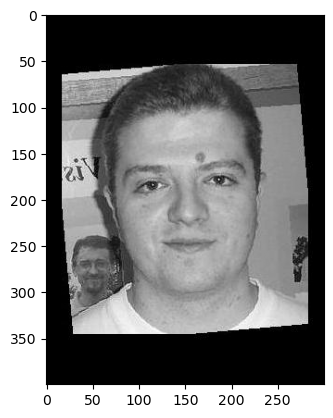

In [16]:
import matplotlib.pyplot as plt

plt.imshow(train[40].reshape(400, 300), cmap='gray')   # 임의로 40번째 데이터 찝음
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

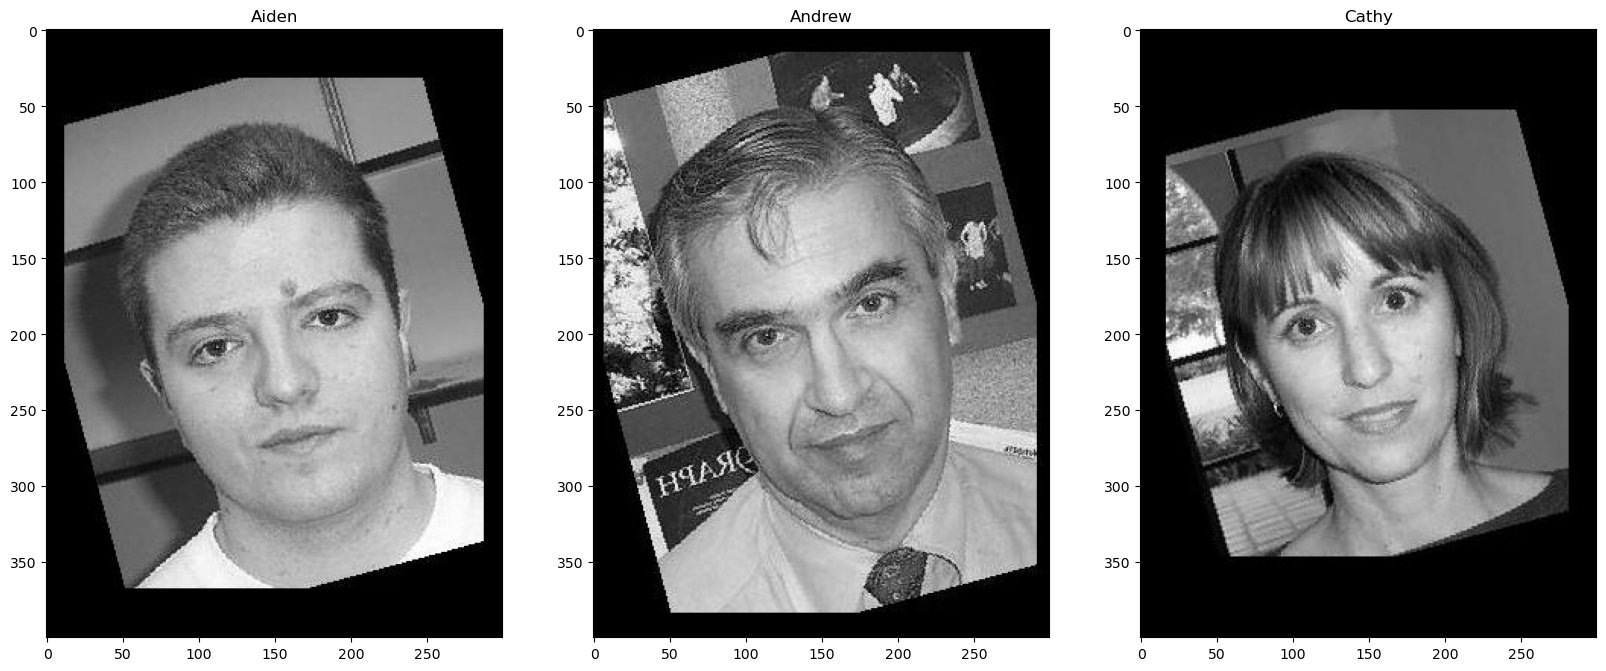

In [18]:
plt.figure(figsize=(20, 20))
orderNo = list(range(0, 1080 * len(dirNames), 1080))
orderNo     # 실제로 각 사람 별로 1080개씩 나왔는지 확인하기 위한 번호 부여

for i in range(1, len(dirNames) + 1):
    plt.subplot(1, len(dirNames), i)
    plt.imshow(train[orderNo[i-1]].reshape(400, 300), cmap='gray')
    plt.title(dirNames[i-1])
    
plt.show

### Target Data

In [19]:
target = np.concatenate(
    [np.zeros(1080), np.ones(1080), np.full(1080, 2)]       # np.full(1080, 2) 혹은 np.ones(1080) * 2
)
target

array([0., 0., 0., ..., 2., 2., 2.], shape=(3240,))

### 정규화

In [20]:
train.shape

(3240, 400, 300)

### 채널 차원 추가와 정규화

In [21]:
train = train.reshape(-1, 400, 300, 1) / 255.0  # 컬러에 1 : 흑백, 3 : 컬러

### Train 과 Test 로 분리

In [22]:
from sklearn.model_selection import train_test_split

trainData, testData, trainTarget, testTarget = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [23]:
print(trainData.shape)
print(testData.shape)
print(trainTarget.shape)
print(testTarget.shape)

(2592, 400, 300, 1)
(648, 400, 300, 1)
(2592,)
(648,)


----
### CNN 만들기

In [24]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [ ]:
model = keras.Sequential()

# ------- 입력층 만들기 -------
model.add(
    Input(shape=(400, 300, 1))
)

# ------ 합성곱층 만들기 -------
# 첫 번째 합성곱층
model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same'
))

model.add(
    keras.layers.MaxPooling2D(2)
)

# 두 번째 합성곱층
model.add(keras.layers.Conv2D(
    64,
    kernel_size=3,
    activation='relu',
    padding='same'
))

model.add(
    keras.layers.MaxPooling2D(2)
)

In [26]:
# ------- 심층 신경망 만들기 --------

# 심층 신경망의 입력층
model.add(
    keras.layers.Flatten()
)

# 심층 신경망의 은닉층
model.add(
    keras.layers.Dense(
        100, activation='relu'
    )
)

# Drop out 층 : 과대적합 방지
model.add(
    keras.layers.Dropout(0.2)   # 20% 정도의 데이터는 학습 시 빼고 함
)

# 출력층
model.add(
    keras.layers.Dense(len(dirNames), activation='softmax')
)

In [27]:
# 각 층의 순서 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 400, 300, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 75, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    48,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,019,219 (183.18 MB)

 Trainable params: 48,019,219 (183.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 손실함수와 학습률 정의
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# 최적의 함수 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_cnn_3P_B.keras")

# Epoch 실행 횟수 제한
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

In [29]:
history = model.fit(
    trainData,
    trainTarget,
    epochs = 10,
    validation_data = (testData, testTarget),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9487 - loss: 0.3382 - val_accuracy: 1.0000 - val_loss: 6.8518e-04
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 1.0000 - loss: 1.1060e-04 - val_accuracy: 1.0000 - val_loss: 1.4102e-04
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 1.0000 - loss: 3.4696e-05 - val_accuracy: 1.0000 - val_loss: 1.4959e-04
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 1.0000 - loss: 9.8278e-06 - val_accuracy: 1.0000 - val_loss: 1.7751e-04
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 1.0000 - loss: 2.6692e-05 - val_accuracy: 1.0000 - val_loss: 4.6966e-05
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 1.0000 - loss: 6.7271e-06 - val_accuracy: 1.0000 - val_loss: 9.8866e-05
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 1.0000 - loss: 3.6442e-06 - val_accuracy: 1.0000 - val_loss: 1.7767e-04
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accura

In [30]:
model.evaluate(trainData, trainTarget)

81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 1.0000 - loss: 6.1474e-07


[6.14744294580305e-07, 1.0]

In [31]:
model.evaluate(testData, testTarget)

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 1.0000 - loss: 4.6966e-05


[4.696587711805478e-05, 1.0]

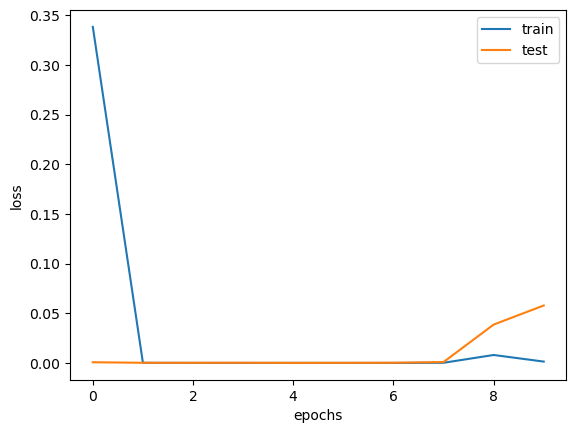

In [32]:
# 시각화 해보기
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

----
### 확인해 보기

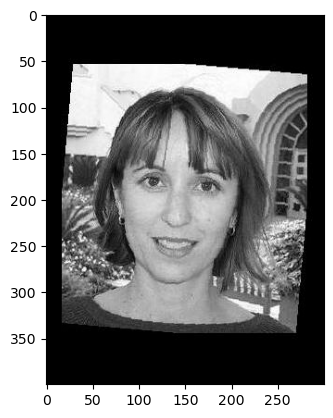

In [33]:
plt.imshow(testData[0].reshape(400, 300), cmap='gray')
plt.show()

In [ ]:
model.predict(testData[:1])     # 3개 데이터 중 확률 나옴.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


array([[2.6282013e-10, 1.6531872e-14, 1.0000000e+00]], dtype=float32)

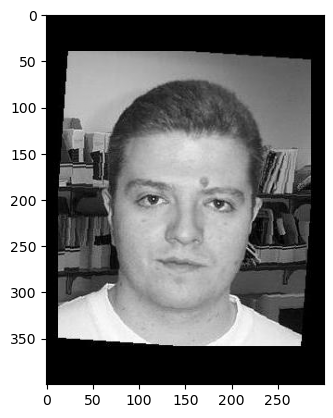

In [36]:
plt.imshow(testData[10].reshape(400, 300), cmap='gray')
plt.show()

In [37]:
model.predict(testData[10:11])     # 3개 데이터 중 확률 나옴.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[1.0000000e+00, 1.6705840e-09, 5.0050006e-11]], dtype=float32)

In [38]:
np.argmax(model.predict(testData[10:11]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


np.int64(0)

In [40]:
dirNames[np.argmax(model.predict(testData[10:11]))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


'Aiden'